# Tiled library design

Builds a pooled single-mutant library for a coding sequence longer than one synthesis oligo. The sequence is split into tiles that each fit on an oligo. Each tile gets its own orthogonal primer pair for selective amplification out of the pool, plus a Golden Gate site pair that drops it into a destination vector holding the rest of the coding sequence.

Point `tiled.starting_vector` at the plasmid you clone into and each tile's destination vector comes out as the full plasmid, ready to order or build (see the destination-plasmids section). Without one, the notebook reports the coding-region cassette for each tile instead.

Edit the input cell, then run the cells in order. Files are written to `out/`.

The layout and QC plots need matplotlib (`uv sync --extra viz`). Reading a plasmid file and writing GenBank maps needs BioPython (`uv sync --extra tiled`). Launch with `uv run --with jupyterlab --extra viz --extra tiled jupyter lab`.

For a short protein that fits on one oligo, use `standard-library-design.ipynb`.

## Input

The default is glucokinase, a 465-residue human gene, so the notebook runs as-is. Replace `protein` and `cds` with your own.

Set `cds` to a native coding sequence when the exact codons matter. Set `cds = None` to codon-optimize the protein into the reference instead.

In [15]:
import tomllib
from library_designer import LibrarySpec, CodonOptimizationParams, TiledAssemblyParams, SubstitutionScan

# ===== EDIT: your protein and options =====
# Default sequences come from the bundled glucokinase example. Replace with your own.
_example = tomllib.load(open("../../examples/gck_tiled.toml", "rb"))
protein = _example["protein_sequence"]   # your protein, one-letter, no stop codon
cds = _example["cds"]                     # native CDS to use verbatim; set to None to codon-optimize instead
substitutions = ["A"]                     # ["A"] alanine scan; list("ACDEFGHIKLMNPQRSTVWY") for full DMS

spec = LibrarySpec(
    name="GCK_tiled_library",
    protein_sequence=protein,
    cds=cds,
    substitutions=substitutions,
    optimization=CodonOptimizationParams(species="e_coli"),   # picks the mutant codon; also builds the reference when cds is None
    tiled=TiledAssemblyParams(
        oligo_budget=300,                 # your synthesis oligo length
        enzyme="BsaI",                    # Golden Gate enzyme
        primer_set="subramanian2018",     # bundled orthogonal set, or a path to your own CSV
    ),
    platform="twist_oligo_pools",
)
spec

name,GCK_tiled_library
protein,465 aa MLDDRARMEAAK...AVACKKACMLGQ
substitutions,A
adaptors,5' 3'
avoid,BsaI + 2 motif pattern(s)
optimization,"e_coli, use_best_codon, iters=100000"
platform,twist_oligo_pools
max_oligo_length,","
seed,0


## Build and tile

`codon_optimize()` fixes one reference sequence and stamps each mutant onto it. `tile()` splits the reference into oligo-sized windows on codon boundaries, assigns each variant to its window, picks a primer pair per tile, and assembles the final oligo. Per-tile primers and destination vectors are stored on `lib.tiles`. Each `vector` is the coding-region cassette, or the full destination plasmid when `tiled.starting_vector` is set.

In [16]:
lib = SubstitutionScan(spec).generate().codon_optimize().tile()
print(len(lib), "variants across", len(lib.tiles), "tiles")
if lib.failed:
    print(len(lib.failed), "could not be built:", lib.failed)

438 variants across 6 tiles
1 could not be built: {'Y273A': 'any synonymous codon for A at position 273 introduces a restricted motif'}


## Tile layout

Each tile is a bar over the region of the coding sequence it covers, labelled with its variant count and primer pair. The top track shows where the mutations fall.

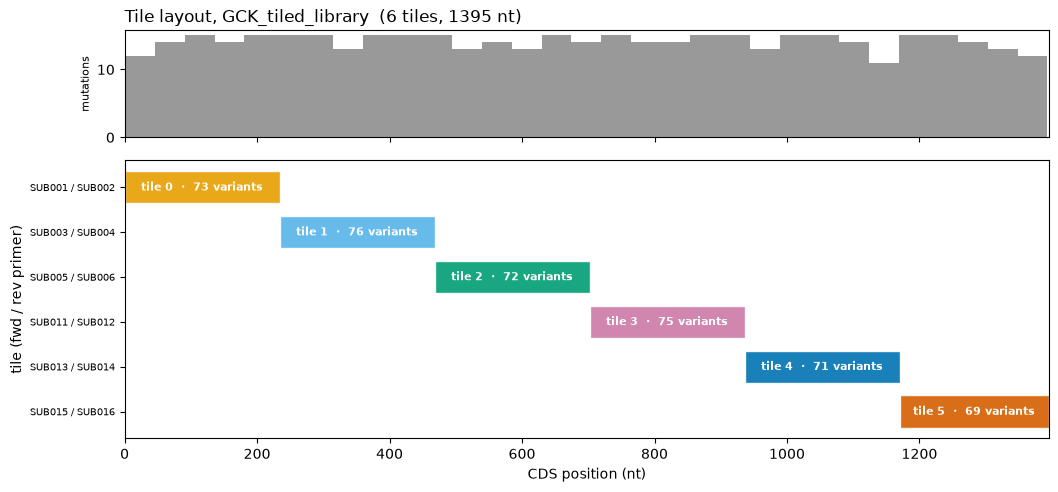

In [17]:
lib.plot_tiling()

## Tiles

One row per tile: the window on the coding sequence, the primer pair that amplifies it, and the length of its destination vector.

In [18]:
import pandas as pd
pd.DataFrame([{
    "tile": t.index, "start": t.start, "end": t.end,
    "forward": f"{t.fwd_id}: {t.fwd}", "reverse": f"{t.rev_id}: {t.rev}",
    "vector_nt": len(t.vector),
} for t in lib.tiles])

,tile,start,end,forward,reverse,vector_nt
0,0,0,234,SUB001: AAACACGTGGCAAACATTCC,SUB002: AAACCGGAGCCATACAGTAC,1179
1,1,234,468,SUB003: AAAGCACTCTTAGGCCTCTG,SUB004: AAAGGGGCCGTCAATATCAG,1179
2,2,468,702,SUB005: AAATAAGACGACGACCCTCG,SUB006: AACGATGATGCTCACTCTCG,1179
3,3,702,936,SUB011: AAGAATTACTGACCCCTCGG,SUB012: AAGACGATCCGAGCCATTAC,1179
4,4,936,1170,SUB013: AAGGAACTATGGCATCGAGC,SUB014: AAGGACTGCATACCAGGTTG,1179
5,5,1170,1395,SUB015: AAGGATATGTAGACACCGCC,SUB016: AAGGCCCAGAAGGATACAAC,1188


## Check

Along with the standard checks, QC confirms each oligo carries exactly the two intended Golden Gate sites (a site formed where a primer meets the insert fails here), stays within the oligo budget, and that each tile's two overhangs differ and are not palindromic.

In [19]:
print(lib.check())

QC report: 438 variants, FAIL
  optimization: 1 failed
    x Y273A
  translation round-trip: 437/437 ok
  BsaI site: no hit(s)
  motif /GGAGG.{8,12}[AG]TG/: no hit(s)
  motif /AGGAG.{8,12}ATG/: no hit(s)


## Codon-usage QC

Relative codon adaptiveness along the coding sequence. The grey line is the wild-type backbone; each point is a variant's stamped codon, coloured by sublibrary. Lower points are synonymous codons chosen to avoid a motif.

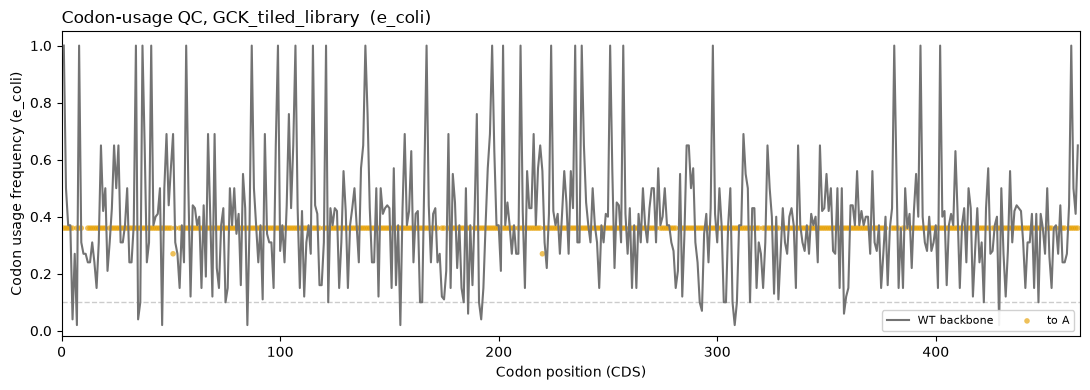

In [20]:
lib.plot_codon_usage()

## Export

Drops any variant that failed to build, then writes the order, cloning, and QC files into `out/`. `to_vectors` writes a one-row-per-tile manifest of destination-vector sequences. With a starting vector set, `to_vector_maps` also writes an annotated GenBank plasmid per tile (see the next section).

In [ ]:
if lib.failed:
    lib.drop_failed()

lib.to_oligo_pool("out/oligos.csv")       # pooled synthesis order, one row per variant
lib.to_primer_order("out/primers.csv")    # per-tile amplification primers, IDT bulk-order format
lib.to_vectors("out/vectors.csv")         # per-tile destination-vector sequences (manifest)
lib.to_full_csv("out/library_full.csv")   # every variant with tile, oligo, and QC columns
lib.to_qc_plots("out/codon_usage.png")    # codon-usage QC figure
lib.to_design_specs(f"out/{lib.spec.name}_design_specs.json")      # spec, reference, primer set, and tool versions

import os
for f in sorted(os.listdir("out")):
    print("out/" + f)

## Destination plasmids

The steps above emit each tile's destination vector as a bare coding-region cassette, because no backbone was given. To get the real plasmids you clone into, point `tiled.starting_vector` at your destination plasmid (`.gb`, `.dna`, or `.fasta`). The WT CDS is located inside it (on either strand), and each tile's vector comes out as the full plasmid with that tile's window replaced by the drop-out.

```python
spec.tiled.starting_vector = "my_destination.gb"
# optional: freeze the CDS already in the plasmid and clone the vectors straight from it,
# which flags SD sites and motifs in that CDS rather than recoding them
spec.tiled.use_vector_cds = True
# optional: name the insert feature when the plasmid holds more than one CDS
spec.tiled.insert_label = "my_gene"

lib = SubstitutionScan(spec).generate().codon_optimize().tile()
lib.to_vector_maps("out/vectors/")   # one annotated GenBank per tile, plus a manifest
```

Each map is the full plasmid with that tile's window swapped for the BsaI drop-out, annotated with the enzyme sites, fused overhangs, retained CDS arms, and your backbone's own features. The whole plasmid is screened for stray BsaI sites that would misdirect assembly. Reading `.gb`/`.dna`/`.fasta` and writing GenBank needs the `tiled` extra (`uv sync --extra tiled`).

## Notes

- The default primer set (`subramanian2018`) has 164 screened primers, enough for about 82 tiles. To use your own, set `tiled.primer_set` to a CSV path (a pool with a `sequence` column, or explicit `forward` and `reverse` columns). A sequence that needs more tiles than the set provides raises an error.
- A position where every synonymous codon would introduce a restricted motif is reported in `lib.failed` and left out of the oligo order.
- `oligo_budget` is the synthesis oligo length. `enzyme` selects the Golden Gate enzyme, `BsaI` by default.